# Training & Evaluation - Windshield Detection   

**Objective**: Train the final YOLOv8 model using the best hyperparameters found during the grid search, monitor performance on the validation set, then evaluate the model once on the test set.

Even though `yolov8s` achieved slightly higher results during cross-validation, the Friedman test (p = 0.677) showed that the difference was not statistically significant.

For this reason, `yolov8n` was selected because it is lighter and faster while keeping similar performance.

**Best config**:  
* Model: yolov8n
* Optimizer: AdamW
* Learning rate: 0.001
* Weight decay: 0.001
* Batch size: 8
* Image size: 512

**Dataset split**:
- Train : 390 images
- Val   : 103 images 
- Test  : 59 images 

The test set is kept completely separate and used only for the final evaluation.

---

### Steps

1. Load the best configuration from `best_config.json` 
2. Train the model on the training set
3. Monitor validation performance and apply early stopping
4. Evaluate the final model on the test set
5. Save the model and final results

## 1. Environment Setup

This section installs the required libraries and imports the packages used for training and evaluation.

In [1]:
!pip install ultralytics --quiet
!pip install pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00


In [2]:
import json
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from ultralytics import YOLO

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports loaded successfully")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports loaded successfully


## 2. Paths & Config

In [3]:
# dataset paths 
DATASET_ROOT  = Path("/kaggle/input/datasets/farahgaida/dataset-windshield/dataset_windshield")

TRAIN_IMG_DIR = DATASET_ROOT / "train" / "images"
TRAIN_LBL_DIR = DATASET_ROOT / "train" / "labels"

VAL_IMG_DIR   = DATASET_ROOT / "val"   / "images"
VAL_LBL_DIR   = DATASET_ROOT / "val"   / "labels"

TEST_IMG_DIR  = DATASET_ROOT / "test"  / "images"
TEST_LBL_DIR  = DATASET_ROOT / "test"  / "labels"

# output paths 
WORK_DIR      = Path("/kaggle/working/final_training")
RESULTS_DIR   = Path("/kaggle/working/results_final")

# results from notebook 1
NB1_RESULTS   = Path("/kaggle/input/datasets/farahgaida/best-config")  

WORK_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["windshield"]

print(f" Dataset root : {DATASET_ROOT}")
print(f" Work dir     : {WORK_DIR}")
print(f" Results dir  : {RESULTS_DIR}")

 Dataset root : /kaggle/input/datasets/farahgaida/dataset-windshield/dataset_windshield
 Work dir     : /kaggle/working/final_training
 Results dir  : /kaggle/working/results_final


## 3. Load Best Config

Load the best hyperparameters obtained from the grid search notebook.

In [4]:
best_config_path = NB1_RESULTS / "best_config.json"

assert best_config_path.exists(), f"best_config.json not found at {best_config_path}"

with open(best_config_path) as f:
    best_config = json.load(f)

# Replace yolov8s with yolov8n
# Friedman test showed no significant difference between both models
# yolov8n is lighter and faster, with lower overfitting risk
best_config["model"] = "yolov8n.pt"

print("=" * 55)
print("Final training configuration")
print("=" * 55)

print(f"Model : {best_config['model']} ")
print(f"Optimizer : {best_config['optimizer']}")
print(f"lr0 : {best_config['lr0']}")
print(f"Batch size : {best_config['batch']}")
print(f"Image size : {best_config['imgsz']}")
print(f"Weight decay : {best_config['weight_decay']}")
print()
if "mAP50_mean" in best_config:
    print(f"Grid search mAP50 : {best_config['mAP50_mean']:.4f} ± {best_config['mAP50_std']:.4f}")

Final training configuration
Model : yolov8n.pt 
Optimizer : AdamW
lr0 : 0.001
Batch size : 8
Image size : 512
Weight decay : 0.001

Grid search mAP50 : 0.9827 ± 0.0052


## 4.  Prepare Dataset Configuration

In [5]:
def collect_pairs(img_dir, lbl_dir):
    """Return valid (image, label) pairs"""
    pairs = []

    for img_path in sorted(img_dir.glob("*.*")):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
            continue

        lbl_path = lbl_dir / f"{img_path.stem}.txt"

        # keep only annotated images
        if lbl_path.exists():
            pairs.append((img_path, lbl_path))

    return pairs


# Load dataset splits
train_pairs = collect_pairs(TRAIN_IMG_DIR, TRAIN_LBL_DIR)
val_pairs   = collect_pairs(VAL_IMG_DIR, VAL_LBL_DIR)
test_pairs  = collect_pairs(TEST_IMG_DIR, TEST_LBL_DIR)

print(f"Train set      : {len(train_pairs)} images")
print(f"Validation set : {len(val_pairs)} images")
print(f"Test set       : {len(test_pairs)} images ")

# Safety checks
assert len(train_pairs) > 0, "No training images found."
assert len(val_pairs) > 0, "No validation images found."
assert len(test_pairs) > 0, "No test images found."

Train set      : 390 images
Validation set : 103 images
Test set       : 59 images 


In [6]:
#  Organize dataset into YOLO format

# Final dataset folder
DATA_DIR = WORK_DIR / "dataset_final"

for split, img_dir, lbl_dir in [
    ("train", TRAIN_IMG_DIR, TRAIN_LBL_DIR),
    ("val",   VAL_IMG_DIR,   VAL_LBL_DIR),
    ("test",  TEST_IMG_DIR,  TEST_LBL_DIR),
]:
    img_out = DATA_DIR / split / "images"
    lbl_out = DATA_DIR / split / "labels"

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for img_src in img_dir.glob("*.*"):
        if img_src.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
            continue

        lbl_src = lbl_dir / f"{img_src.stem}.txt"

        # keep only valid pairs
        if lbl_src.exists():
            shutil.copy2(img_src, img_out / img_src.name)
            shutil.copy2(lbl_src, lbl_out / lbl_src.name)


#  create data.yaml 
DATA_YAML = DATA_DIR / "data.yaml"

yaml_data = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val":   "val/images",
    "test":  "test/images",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open(DATA_YAML, "w") as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"Dataset folder created: {DATA_DIR}")
print(f"data.yaml written: {DATA_YAML}")

Dataset folder created: /kaggle/working/final_training/dataset_final
data.yaml written: /kaggle/working/final_training/dataset_final/data.yaml


## 5. Final Training

In [7]:
# Load model
model = YOLO(best_config["model"])

# training config
train_params = {
    
    # Data 
    "data":         str(DATA_YAML),
    "imgsz":        best_config["imgsz"],
    "batch":        best_config["batch"],

    # Optimizer 
    "optimizer":    best_config["optimizer"],
    "lr0":          best_config["lr0"],
    "weight_decay": best_config["weight_decay"],

    # Training schedule 
    "epochs":       100,
    "patience":     20,

    #  Hardware 
    "device":       0,
    "workers":      2,
    "seed":         SEED,

    #  Output 
    "project":      str(WORK_DIR / "runs"),
    "name":         "final_yolov8n",
    "save":         True,
    "plots":        True,
    "verbose":      False,
}

print("Starting final training...")
print(f"Model      : {best_config['model']}")
print(f"Epochs     : {train_params['epochs']} (patience={train_params['patience']})")
print(f"Train size : {len(train_pairs)} images")
print(f"Val size   : {len(val_pairs)} images")
print()

t0 = time.time()
results = model.train(**train_params)
duration = (time.time() - t0) / 60

print(f"\nTraining completed in {duration:.1f} minutes")

Starting final training...
Model      : yolov8n.pt
Epochs     : 100 (patience=20)
Train size : 390 images
Val size   : 103 images

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/final_training/dataset_final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt

## 6. Final Evaluation on Test Set

In [8]:

# Load the best trained model 
run_dir = WORK_DIR / "runs" / "final_yolov8n"
best_pt = run_dir / "weights" / "best.pt"

assert best_pt.exists(), f"best.pt not found at {best_pt}"

final_model = YOLO(str(best_pt))

print("=" * 55)
print("final evaluation on test set")
print("=" * 55)

#  evaluation on the test set 
eval_results = final_model.val(
    data=str(DATA_YAML),
    split="test",   
    imgsz=best_config["imgsz"],
    device=0,
    verbose=True,
)

metrics = eval_results.results_dict

mAP50     = float(metrics.get("metrics/mAP50(B)", 0))
mAP50_95  = float(metrics.get("metrics/mAP50-95(B)", 0))
precision = float(metrics.get("metrics/precision(B)", 0))
recall    = float(metrics.get("metrics/recall(B)", 0))

print()
print(f"mAP50    : {mAP50:.4f}")
print(f"mAP50-95 : {mAP50_95:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print("=" * 55)

final evaluation on test set
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1042.5±326.6 MB/s, size: 36.0 KB)
val: Scanning /kaggle/working/final_training/dataset_final/test/labels... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 1.3Kit/s 0.0s
val: New cache created: /kaggle/working/final_training/dataset_final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.1it/s 1.0s
                   all         59         69      0.954      0.942      0.967      0.615
Speed: 2.3ms preprocess, 5.1ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

mAP50    : 0.9670
mAP50-95 : 0.6154
Precision: 0.9543
Recall   : 0.9420


## 7. Comparison: Grid Search CV vs Final Test

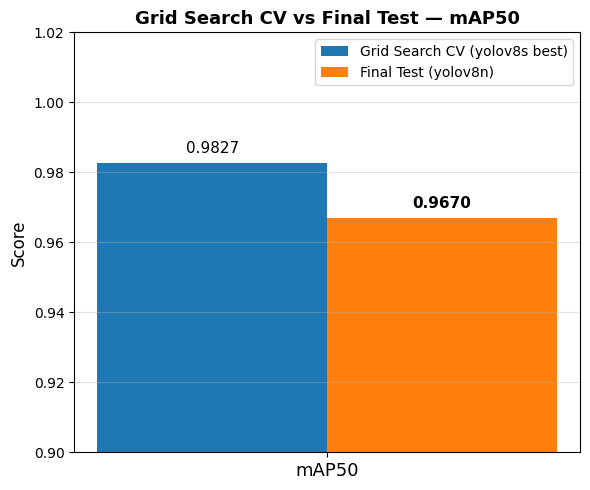

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

metrics_labels = ["mAP50"]

# CV results
cv_values   = [best_config["mAP50_mean"]]

# Final test results
test_values = [mAP50]

x = np.arange(len(metrics_labels))
width = 0.35

bars1 = ax.bar(x - width/2, cv_values,   width, label="Grid Search CV (yolov8s best)")
bars2 = ax.bar(x + width/2, test_values, width, label="Final Test (yolov8n)")

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=11)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=13)
ax.set_ylim(0.9, 1.02)  # zoom pour rendre la différence visible
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Grid Search CV vs Final Test — mAP50", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cv_vs_test_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Training Curves

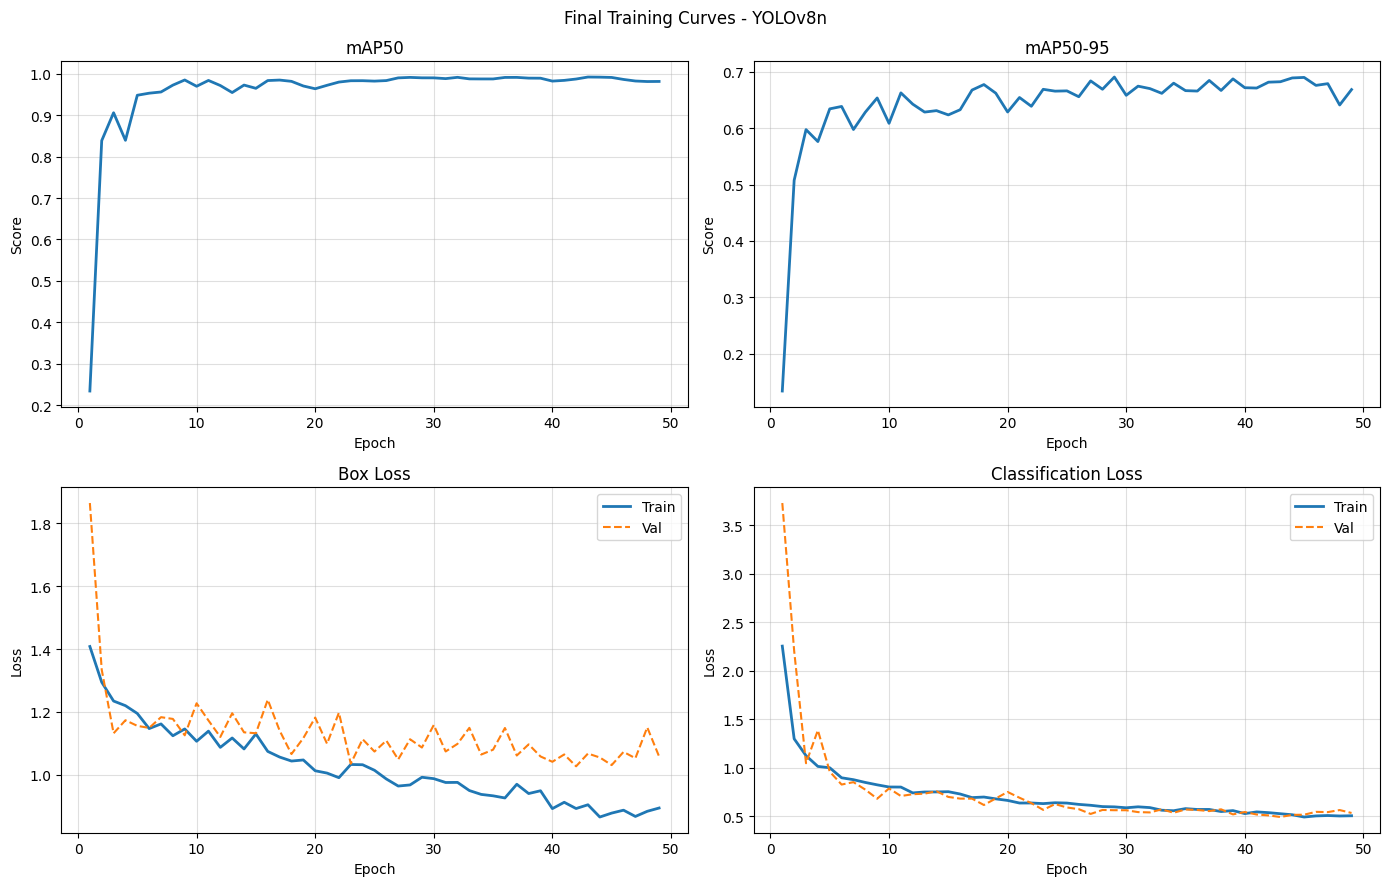

In [10]:
#  Load results.csv from training run 
results_csv = run_dir / "results.csv"

if results_csv.exists():
    df_train = pd.read_csv(results_csv)
    df_train.columns = df_train.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # mAP50
    axes[0, 0].plot(df_train["epoch"], df_train["metrics/mAP50(B)"], linewidth=2)
    axes[0, 0].set_title("mAP50")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Score")
    axes[0, 0].grid(alpha=0.4)

    # mAP50-95
    axes[0, 1].plot(df_train["epoch"], df_train["metrics/mAP50-95(B)"], linewidth=2)
    axes[0, 1].set_title("mAP50-95")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Score")
    axes[0, 1].grid(alpha=0.4)

    # Box loss
    axes[1, 0].plot(df_train["epoch"], df_train["train/box_loss"], label="Train", linewidth=2)
    axes[1, 0].plot(df_train["epoch"], df_train["val/box_loss"], label="Val", linestyle="--")
    axes[1, 0].set_title("Box Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.4)

    # Cls loss
    axes[1, 1].plot(df_train["epoch"], df_train["train/cls_loss"], label="Train", linewidth=2)
    axes[1, 1].plot(df_train["epoch"], df_train["val/cls_loss"], label="Val", linestyle="--")
    axes[1, 1].set_title("Classification Loss")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Loss")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.4)

    plt.suptitle("Final Training Curves - YOLOv8n")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"results.csv not found at {results_csv}")

9. Save Final Model 

In [11]:
# Save best model for final use
final_model_path = RESULTS_DIR / "best_model.pt"
shutil.copy2(best_pt, final_model_path)

print("Best model saved")
print(f"Epochs trained: {len(pd.read_csv(run_dir/'results.csv')) if (run_dir/'results.csv').exists() else 'N/A'}")

Best model saved
Epochs trained: 49
